In [2]:
# !pip install -r requirements.txt
import os

In [ ]:
from imports import *

# Gamma matrix

In [3]:
base_dir = "data_testcode"

gamma_file = os.path.join(base_dir,'Gamma_list.npy'); days_file = os.path.join(base_dir, 'days.npy')
# gamma_file = "data/Gamma_list.npy"; days_file = "data/days.npy"

Gamma_list = np.load(gamma_file, allow_pickle=True)
days = np.load(days_file, allow_pickle=True)

# Figure2 and Figure 7

Generating Figure 2 (Log Kurtosis Box Plot)...


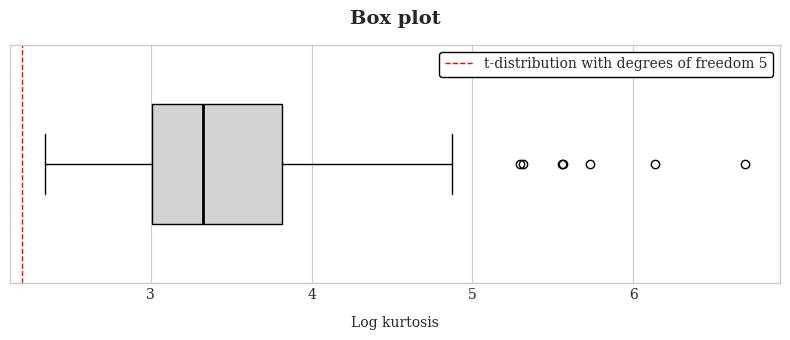

Reference Log Kurtosis (t_5): 2.1972
Sample Mean Log Kurtosis: 3.4959
Sample Median Log Kurtosis: 3.3252


In [4]:
# figure2 
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'  # 폰트

def plot_figure2_log_kurtosis(Gamma_list: list[np.ndarray]):
  
    print("Generating Figure 2 (Log Kurtosis Box Plot)...")
    
    # 1. 시계열 데이터 구성 (Extract Diagonals)
    T = len(Gamma_list)
    if T == 0:
        print("Error: Gamma_list is empty.")
        return

    p = Gamma_list[0].shape[0]
    daily_variances = np.zeros((T, p))

    for t, Gamma in enumerate(Gamma_list): # iterable(자료형) -> enumerate object(열거 객체) index, value 포함하도록
        daily_variances[t, :] = np.diag(Gamma)
        
    # 2. 각 자산별 첨도(Kurtosis) 계산
    raw_kurtoses = stats.kurtosis(daily_variances, axis=0, fisher=False)
    
    # 3. 로그 변환 (Log Kurtosis)
    log_kurtoses = np.log(raw_kurtoses)
    
    # 4. 기준선 계산 (t-distribution with df=5)
    ref_kurtosis = 9.0
    ref_log_kurtosis = np.log(ref_kurtosis)
    
    # 5. 
    plt.figure(figsize=(8, 3.5))
    box = plt.boxplot(
        log_kurtoses, 
        vert=False,          # 가로 방향
        patch_artist=True,   # 박스 색칠 가능하게
        widths=0.5
    )
    
    for patch in box['boxes']:
        patch.set_facecolor('lightgray') # 박스 내부 회색
        patch.set_edgecolor('black')
        
    for median in box['medians']:
        median.set_color('black')
        median.set_linewidth(2)
        
    # 기준선 (Red Dashed Line)
    plt.axvline(
        ref_log_kurtosis, 
        color='red', 
        linestyle='--', 
        linewidth=1,
        label='t-distribution with degrees of freedom 5'
    )
    
    # 레이블 및 타이틀
    plt.title('Box plot', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Log kurtosis', labelpad=10)
    
    plt.yticks([])
    plt.legend(frameon=True, framealpha=1, edgecolor='black', loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    # 수치 확인용 출력
    print(f"Reference Log Kurtosis (t_5): {ref_log_kurtosis:.4f}")
    print(f"Sample Mean Log Kurtosis: {np.mean(log_kurtoses):.4f}")
    print(f"Sample Median Log Kurtosis: {np.median(log_kurtoses):.4f}")

# 실행
if 'Gamma_list' in locals():
    plot_figure2_log_kurtosis(Gamma_list)
else:
    print("Gamma_list가 메모리에 없습니다. 먼저 데이터를 생성해주세요.")

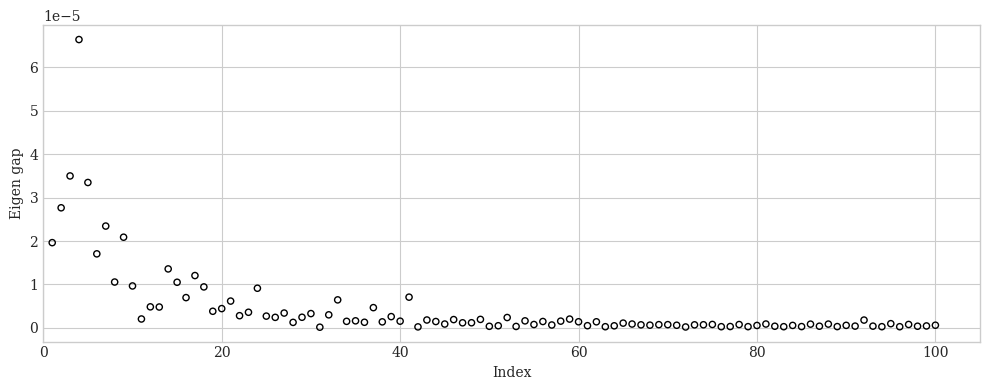

In [8]:
# figure7
def idiosyncratic_matrix(Gd: np.ndarray, r: int) -> np.ndarray:
    w, V = la.eigh(Gd) 
    idx = np.argsort(w)[::-1]
    w = w[idx]
    V = V[:, idx]

    if r <= 0:
        Gi = Gd.copy()
    else:
        # 상위 r개의 팩터 성분을 제거 
        Wf = w[:r]
        Vf = V[:, :r]
        factor_part = (Vf * Wf) @ Vf.T
        Gi = Gd - factor_part

    # Gi = 0.5 * (Gi + Gi.T) 
    return Gi

def plot_figure7(Gamma_list: list[np.ndarray], r_hat: int = 3, max_k: int = 100):
    # average of idiosyncratic estimators
    Gi_bar = np.mean([idiosyncratic_matrix(Gd, r=r_hat) for Gd in Gamma_list], axis=0)
    Gi_bar = 0.5 * (Gi_bar + Gi_bar.T)

    # eigenvalues of average idiosyncratic matrix
    w, _ = la.eigh(Gi_bar)
    w = np.sort(w)[::-1]  # desc

    gaps = w[:max_k] - w[1:max_k+1]

    x = np.arange(1, max_k + 1)

    plt.figure(figsize=(10, 4))
    plt.scatter(x, gaps, facecolors="none", edgecolors="black", s=20)
    plt.xlabel("Index")
    plt.ylabel("Eigen gap")
    plt.xlim(0, max_k + 5)
    plt.tight_layout()
    plt.show()

plot_figure7(Gamma_list, r_hat=3, max_k=100)

# Figure6